In [2]:
from pathlib import Path
from ase.io import read
import matplotlib.pyplot as plt 
import pandas as pd

plt.style.use("/home/jvc/ZnO_database/mpl_themes/jvc.mplstyle")

GALLERY = "/home/jvc/ZnO_database/gallery"

In [3]:
data = [(f.name, read(f, format='espresso-out').get_total_energy()) for f in Path().cwd().glob('kpoint.*.out')]
data.sort(key=lambda x: x[1], reverse=True)
data

[('kpoint.4.out', -12270.022961624592),
 ('kpoint.5.out', -12270.044893727874),
 ('kpoint.6.out', -12270.050365120827),
 ('kpoint.7.out', -12270.051805691492),
 ('kpoint.8.out', -12270.052364885429),
 ('kpoint.9.out', -12270.05255958288),
 ('kpoint.10.out', -12270.052637135324),
 ('kpoint.11.out', -12270.052685843702),
 ('kpoint.12.out', -12270.05270666041),
 ('kpoint.14.out', -12270.052719585818),
 ('kpoint.13.out', -12270.052722034843)]

In [4]:
with open('energies.csv', 'w') as file:
    for dup in data:
        filename, ener = dup
        file.write(f'{filename}, {ener}\n')

In [5]:
! cat "energies.csv"

kpoint.4.out, -12270.022961624592
kpoint.5.out, -12270.044893727874
kpoint.6.out, -12270.050365120827
kpoint.7.out, -12270.051805691492
kpoint.8.out, -12270.052364885429
kpoint.9.out, -12270.05255958288
kpoint.10.out, -12270.052637135324
kpoint.11.out, -12270.052685843702
kpoint.12.out, -12270.05270666041
kpoint.14.out, -12270.052719585818
kpoint.13.out, -12270.052722034843


In [6]:
df = pd.read_csv('energies.csv', names=['file', 'E (eV)'])
df = df.sort_values(by='E (eV)', ascending=False).reset_index(drop=True)
df['k'] = df['file'].apply(lambda x: x.split('.')[1])
df['E_atom (eV)'] = df['E (eV)'] / 4
df['dE_atom (meV)'] = (df['E_atom (eV)'] - df['E_atom (eV)'].min()) * 1_000
df

,file,E (eV),k,E_atom (eV),dE_atom (meV)
0,kpoint.4.out,-12270.022962,4,-3067.505740,7.440103
1,kpoint.5.out,-12270.044894,5,-3067.511223,1.957077
2,kpoint.6.out,-12270.050365,6,-3067.512591,0.589229
3,kpoint.7.out,-12270.051806,7,-3067.512951,0.229086
4,kpoint.8.out,-12270.052365,8,-3067.513091,0.089287
5,kpoint.9.out,-12270.052560,9,-3067.513140,0.040613
6,kpoint.10.out,-12270.052637,10,-3067.513159,0.021225
7,kpoint.11.out,-12270.052686,11,-3067.513171,0.009048
8,kpoint.12.out,-12270.052707,12,-3067.513177,0.003844
9,kpoint.14.out,-12270.052720,14,-3067.513180,0.000612


In [7]:
diffE_meV = df['dE_atom (meV)'].to_numpy()
diffE_meV

array([7.44010256e+00, 1.95707674e+00, 5.89228504e-01, 2.29085838e-01,
       8.92873536e-02, 4.06129907e-02, 2.12248797e-02, 9.04778517e-03,
       3.84360828e-03, 6.12256372e-04, 0.00000000e+00])

In [8]:
df.loc[df['E_atom (eV)'].idxmin()]

file             kpoint.13.out
E (eV)           -12270.052722
k                           13
E_atom (eV)       -3067.513181
dE_atom (meV)              0.0
Name: 10, dtype: object

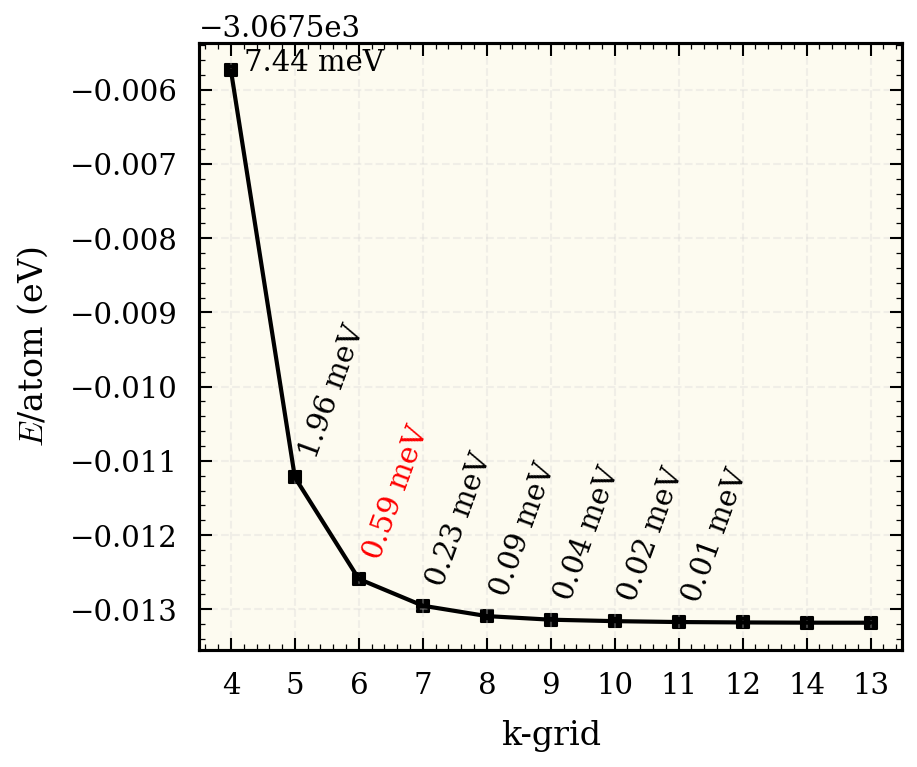

In [12]:
fig = plt.figure(figsize=(6,5), layout="constrained")

plt.ylabel(r'$E$/atom (eV)', labelpad=10)
plt.xlabel('k-grid')

sc = plt.scatter(df['k'], df['E_atom (eV)'], marker='s', color='k')
plt.plot(df['k'], df['E_atom (eV)'], color='k')

# plt.scatter(df.loc[10,'k'], df.loc[10, 'E_atom (eV)'], color='orange', marker='*', label='min(E)')

for x,y, dE in zip(df['k'], df['E_atom (eV)'], diffE_meV):
    if x == '4':
        plt.text(0.2, y, s=f'{dE:.2f} meV', rotation=0)
    elif x == '6':
        plt.text(x, y+3e-4, s=f'{dE:.2f} meV', rotation=70, color='red')
    elif x in ['12', '13', '14']:
        continue
    else:
        plt.text(x, y+3e-4, s=f'{dE:.2f} meV', rotation=70)

plt.savefig(f'{GALLERY}/kconvergence-pseudo_dojo.pdf', format='pdf')        
plt.grid(alpha=0.3, ls='--')
plt.show()



In [10]:
df["E_atom (eV)"] - df["E_atom (eV)"].min()

0     7.440103e-03
1     1.957077e-03
2     5.892285e-04
3     2.290858e-04
4     8.928735e-05
5     4.061299e-05
6     2.122488e-05
7     9.047785e-06
8     3.843608e-06
9     6.122564e-07
10    0.000000e+00
Name: E_atom (eV), dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ase.io import read
from pathlib import Path


def get_energies(scf_outputs) -> list[list[str, float]]:
    """
    Lê todos os arquivos scf.*.out, extrai a energia por átomo em eV.

    Output: [['scf*.out', E/atom (eV)], ...]
    """
    NUM_ATOMOS = 4

    files = list(Path(scf_outputs).glob(f"kpoints*.out"))
    energies = [
        read(f, format="espresso-out").get_total_energy() / NUM_ATOMOS for f in files
    ]

    data: list[list[str, float]] = [[f.name, e] for f, e in zip(files, energies)]
    # Ordem descrescente de energia.
    data.sort(key=lambda x: x[1], reverse=True)
    return data


def transform_data_to_df(data: list) -> pd.DataFrame:
    """
    Cria um DataFrame com File	E/atom	dE_ref_meV	dE_consec_meV.

    dE_ref_meV: E_min - E_i
    dE_consec_meV : E_{i+1} - E_{i}
    """
    get_deltaE_consec = lambda x: np.abs(np.r_[0, np.diff(x)])
    get_deltaEref = lambda x: np.abs(x - np.min(x))

    df = pd.DataFrame(data, columns=["File", "E/atom"])
    df["dE_ref_meV"] = get_deltaEref(df["E/atom"]) * 1_000
    df["dE_consec_meV"] = get_deltaE_consec(df["E/atom"]) * 1_000

    return df


def plot_convergence_kpoints(df: pd.DataFrame, pseudopot_title: str, save: bool = False):
    """
    Args:
        data: DataFrame with columns: File	E/atom	dE_ref_meV	dE_consec_meV
        pseudopot_title: string containing info about selected pseudopotential.
    """

    kpoints = np.arange(4, 14)
    THR = 2.0  # meV

    E_per_atom = df["E/atom"].to_numpy()
    dE_ref_meV = df["dE_ref_meV"].to_numpy()
    dE_consec_meV = df["dE_consec_meV"].to_numpy()

    fig, (axE, axdE) = plt.subplots(
        2, 1, sharex=True, figsize=(6, 5), gridspec_kw={"hspace": 0.05}
    )

    # === Painel (a): energia por átomo vs cutoff ===
    axE.set_title(pseudopot_title)
    axE.set_ylabel(r"$E$ (eV/atom)")
    axE.plot(kpoints, E_per_atom, marker="s", ls="-", color="black", label=r"$E_i$")
    axE.scatter(kpoints[-1], E_per_atom[-1], marker="v", color="black")
    axE.legend()

    # === Painel (b): diferenças em meV/átomo ===

    # Módulo das diferenças
    dE_ref_abs = np.abs(dE_ref_meV)
    dE_consec_abs = np.abs(dE_consec_meV)

    # Limite superior do eixo y na região de interesse
    YMAX = 10.0  # meV (ajuste se quiser)

    # Versões "clipadas" para plotar
    dE_ref_plot = np.clip(dE_ref_abs, 0, YMAX)
    dE_consec_plot = np.clip(dE_consec_abs, 0, YMAX)

    axdE.plot(
        kpoints, dE_ref_plot, marker="s", ls="-", label=r"$|E_i - E_{\mathrm{ref}}|$"
    )
    axdE.plot(kpoints, dE_consec_plot, marker="o", ls="--", label=r"$|E_i - E_{i-1}|$")

    # Marcar pontos que saturaram (valores reais > YMAX)
    mask_ref_sat = dE_ref_abs > YMAX
    mask_consec_sat = dE_consec_abs > YMAX

    axdE.scatter(
        kpoints[mask_ref_sat],
        np.full(mask_ref_sat.sum(), YMAX),
        marker="v",
        s=40,
        color="C0",
    )
    axdE.scatter(
        kpoints[mask_consec_sat],
        np.full(mask_consec_sat.sum(), YMAX),
        marker="v",
        s=40,
        color="C1",
    )

    # Faixa de tolerância 0–2 meV/átomo
    axdE.axhspan(0.0, THR, alpha=0.15, color="red")

    axdE.set_ylabel(r"$\Delta E$ (meV/atom)")
    axdE.set_xlabel(r"Kinetic energy cutoff (Ry)", labelpad=10)
    axdE.set_ylim(0, YMAX)

    axdE.legend(fontsize=8, loc="upper right")
    
    fig.savefig(nome_figura, format=formato, bbox_inches="tight")

    plt.show()


if __name__ == "__main__":
    plt.style.use("/home/jvc/QEspresso7.2/ZnO_database/mpl_themes/jvc.mplstyle")
    # GBRV
    # scfs_path =  "/home/jvc/LDA_Study/pseudos/GBRV/scf_outputs"
    # data = get_energies(scfs_path)
    # df = transform_data_to_df(data)
    # plot_convergence(df, pseudopot_title="GBRV LDA USPP", save = True)

    # Pseudo-Dojo
    scfs_path = "/home/jvc/LDA_Study/pseudos/pseudo_dojo/scf_outputs"
    data = get_energies(scfs_path)
    df = transform_data_to_df(data)
    plot_convergence(df, pseudopot_title="Pseudo-Dojo LDA NC", save=True)
